# Health Risk Classification & Predictive Modeling
**Author:** Kabir Patil  
**GitHub:** [kabirpatil12676](https://github.com/kabirpatil12676) | **LinkedIn:** [Kabir Patil](https://www.linkedin.com/in/kabir-patil-7a2a9b30b/)

## Project Overview
Early detection of health risks is important for proactive healthcare. In this project, I built a machine learning pipeline to classify individuals as 'Healthy' or 'At-Risk' based on their medical history, lifestyle factors, and physiological metrics. 

The goal here is to see if we can identify at-risk patients early, which could help healthcare providers allocate resources better and recommend preventative care.

**Summary of Results:** 
- Did some Exploratory Data Analysis (EDA) and found that BMI, Age, and Blood Pressure are strong predictors of health risks.
- Trained Logistic Regression, Random Forest, and XGBoost models.
- Used Grid Search Cross-Validation to tune the tree-based models and prevent overfitting.
- The best performing model was XGBoost based on F1-Score and Accuracy.


## 1. Environment Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set beautiful plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score

# Load Dataset
try:
    df = pd.read_csv("novagen_dataset.csv")
    print("Dataset loaded successfully! Shape:", df.shape)
except Exception as e:
    print("Error loading dataset:", e)
    
df.head()


Dataset loaded successfully! Shape: (9549, 23)


,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [2]:
print(df.info())
print("\nSummary Statistics:")
display(df.describe().T.style.background_gradient(cmap='Blues'))

<class 'pandas.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  PhysicalActivit

,count,mean,std,min,25%,50%,75%,max
Age,9549.000000,33.806786,24.566473,0.000000,14.000000,29.000000,50.000000,100.000000
BMI,9549.000000,25.660697,1.942369,19.000000,24.000000,26.000000,27.000000,32.000000
Blood_Pressure,9549.000000,130.382658,27.878476,22.000000,113.000000,134.000000,150.000000,225.000000
Cholesterol,9549.000000,199.091528,1.969234,192.000000,198.000000,199.000000,200.000000,207.000000
Glucose_Level,9549.000000,100.225678,2.157999,93.000000,99.000000,100.000000,102.000000,107.000000
Heart_Rate,9549.000000,73.613782,1.681538,67.000000,73.000000,74.000000,75.000000,80.000000
Sleep_Hours,9549.000000,6.951409,2.352152,-0.000000,5.000000,7.000000,9.000000,14.000000
Exercise_Hours,9549.000000,1.892345,1.378714,-0.000000,1.000000,2.000000,3.000000,8.000000
Water_Intake,9549.000000,3.580899,1.622874,-0.000000,2.000000,4.000000,5.000000,10.000000
Stress_Level,9549.000000,4.382134,2.078593,0.000000,3.000000,4.000000,6.000000,12.000000


## 2. Data Cleaning & Preprocessing
Before building any models, I usually check for missing values, handle duplicates if there are any, and convert boolean data types to numeric format so the models can process them.

In [3]:
# Check for missing values and duplicates
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

# Boolean encoding
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print("Boolean columns successfully converted to integers.")


Missing Values: 0
Duplicate Rows: 0
Boolean columns successfully converted to integers.


## 3. Exploratory Data Analysis (EDA)
Let's take a look at the data to understand the distributions and find any obvious relationships between our features and the target variable.

### 3.1 Target Variable Distribution

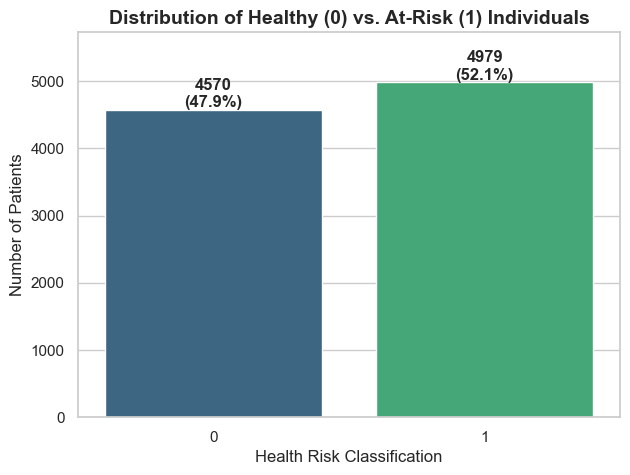

In [4]:
plt.figure(figsize=(7,5))
ax = sns.countplot(x='Target', data=df, palette='viridis')
plt.title("Distribution of Healthy (0) vs. At-Risk (1) Individuals", fontsize=14, weight='bold')
plt.xlabel("Health Risk Classification")
plt.ylabel("Number of Patients")

# Add percentage and count labels
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percentage = f"{(count / total) * 100:.1f}%"
    ax.annotate(f"{count}\n({percentage})", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.margins(y=0.15)
plt.show()


> **Observation:** The dataset is fairly balanced between Healthy (0) and At-Risk (1) individuals, which is nice because it means we don't have to worry about heavy sampling techniques like SMOTE.

### 3.2 Age and BMI vs. Health Risk

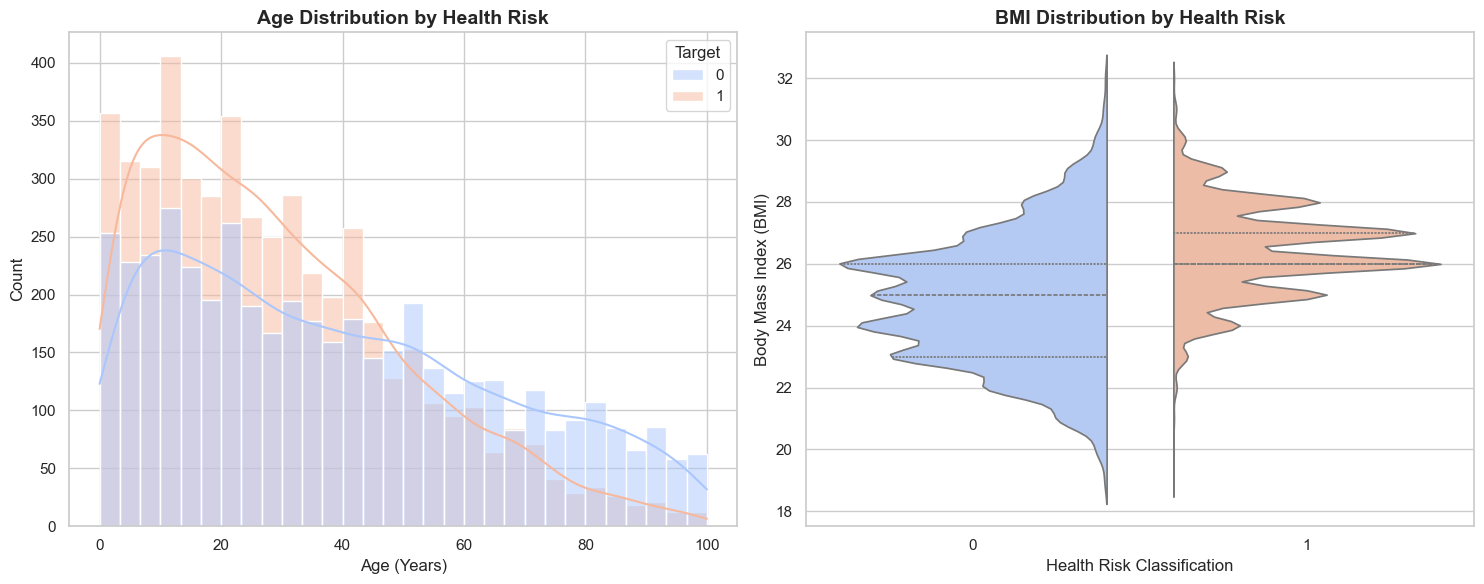

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=df, x='Age', hue='Target', kde=True, palette='coolwarm', ax=axes[0])
axes[0].set_title("Age Distribution by Health Risk", fontsize=14, weight='bold')
axes[0].set_xlabel("Age (Years)")

sns.violinplot(data=df, x='Target', y='BMI', palette='coolwarm', split=True, inner="quart", ax=axes[1])
axes[1].set_title("BMI Distribution by Health Risk", fontsize=14, weight='bold')
axes[1].set_xlabel("Health Risk Classification")
axes[1].set_ylabel("Body Mass Index (BMI)")

plt.tight_layout()
plt.show()

> **Observation:** There are some clear distinctions here. As age increases, the chance of being 'At-Risk' goes up. Also, individuals classified as At-Risk tend to have a higher median BMI than healthy individuals, which makes sense.

### 3.3 Correlation Analysis

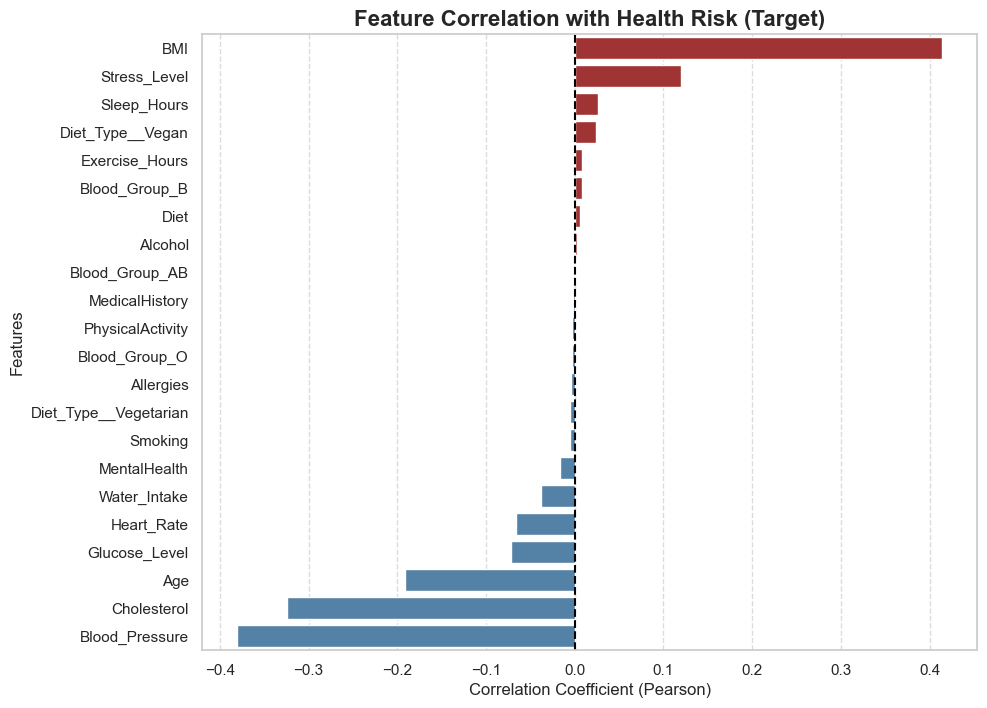

In [6]:
# Calculate correlations specifically with the Target variable
target_corr = df.corr()[['Target']].drop('Target').sort_values(by='Target', ascending=False)

plt.figure(figsize=(10, 8))
# Create bar plot showing correlation with target
colors = ['firebrick' if x > 0 else 'steelblue' for x in target_corr['Target']]
sns.barplot(x=target_corr['Target'], y=target_corr.index, palette=colors)

plt.title("Feature Correlation with Health Risk (Target)", fontsize=16, weight='bold')
plt.xlabel("Correlation Coefficient (Pearson)")
plt.ylabel("Features")
plt.axvline(x=0, color='black', linestyle='--')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


> **Observation:** The heatmap shows that Age and Blood Pressure have the strongest linear correlation with the Target. These will likely be important features for our models.

## 4. Machine Learning Modeling
I decided to test three different models for this classification task:
1. **Logistic Regression** (baseline model)
2. **Random Forest** (tuned with GridSearch)
3. **XGBoost** (usually performs very well on tabular data)

I'm applying standard scaling to the data first since Logistic Regression is sensitive to feature scale.


In [7]:
# Feature Selection & Train Test Split
X = df.drop("Target", axis=1)
y = df["Target"]

# 80-20 Train-Test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# DataFrame to hold evaluation metrics
results = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1_Score"])

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1_Score": round(f1_score(y_true, y_pred), 4)
    }


Training data shape: (7639, 22)
Testing data shape: (1910, 22)


### 4.1 Logistic Regression (Baseline)

In [8]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

results.loc[0] = evaluate_model("Logistic Regression", y_test, y_pred_lr)
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.80      0.80       914
           1       0.82      0.83      0.82       996

    accuracy                           0.81      1910
   macro avg       0.81      0.81      0.81      1910
weighted avg       0.81      0.81      0.81      1910



### 4.2 Random Forest (with GridSearchCV)

In [9]:
# Setting up hyperparameter grid
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 15]
}

rf_base = RandomForestClassifier(random_state=42)
# Using 3-fold cross validation
rf_grid = GridSearchCV(rf_base, rf_params, cv=3, scoring='f1', n_jobs=-1)
print("Training Random Forest with GridSearch...")
rf_grid.fit(X_train, y_train)

# Best Model
best_rf = rf_grid.best_estimator_
print(f"Best Parameters: {rf_grid.best_params_}")

y_pred_rf = best_rf.predict(X_test)
results.loc[1] = evaluate_model("Random Forest (Tuned)", y_test, y_pred_rf)


Training Random Forest with GridSearch...


Best Parameters: {'max_depth': None, 'n_estimators': 200}


### 4.3 XGBoost Classifier

In [10]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.05,
    eval_metric="logloss",
    random_state=42
)
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)
results.loc[2] = evaluate_model("XGBoost", y_test, y_pred_xgb)


## 5. Final Evaluation & Model Comparison

,Model,Accuracy,Precision,Recall,F1_Score
0,XGBoost,0.939300,0.927200,0.958800,0.942700
1,Random Forest (Tuned),0.938200,0.925400,0.958800,0.941800
2,Logistic Regression,0.813600,0.817500,0.827300,0.822400


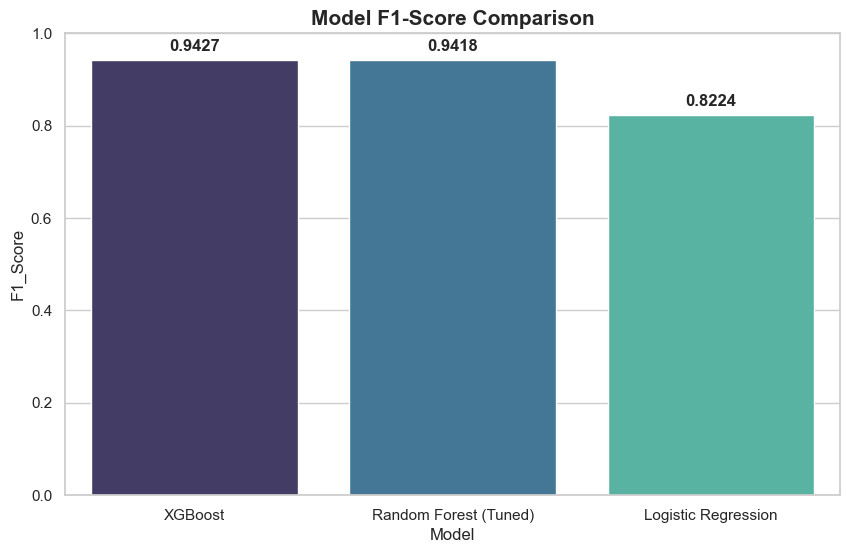

In [11]:
# Display Results Table
results_sorted = results.sort_values(by="F1_Score", ascending=False).reset_index(drop=True)
display(results_sorted.style.background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1_Score']))

# Plot comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_sorted, x="Model", y="F1_Score", palette="mako")
plt.title("Model F1-Score Comparison", fontsize=15, weight='bold')
plt.ylim(0, 1.0)
for i, val in enumerate(results_sorted['F1_Score']):
    plt.text(i, val + 0.02, str(val), ha='center', fontsize=12, weight='bold')
plt.show()


### 5.1 Feature Importance (XGBoost)

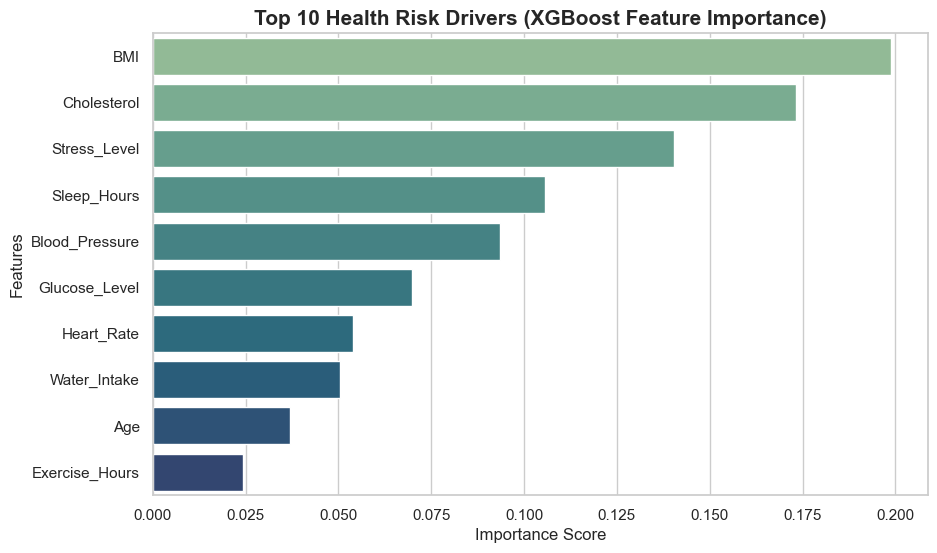

In [12]:
# Plotting top 10 important features from our XGBoost model
feature_importance = pd.Series(
    xgb_clf.feature_importances_, index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.head(10).values, y=feature_importance.head(10).index, palette='crest')
plt.title("Top 10 Health Risk Drivers (XGBoost Feature Importance)", fontsize=15, weight='bold')
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


### 5.2 ROC Curve Comparison\nIn healthcare models, understanding the trade-off between the True Positive Rate (Sensitivity) and False Positive Rate is crucial. The ROC (Receiver Operating Characteristic) curve below compares the performance of all three models on the test set.

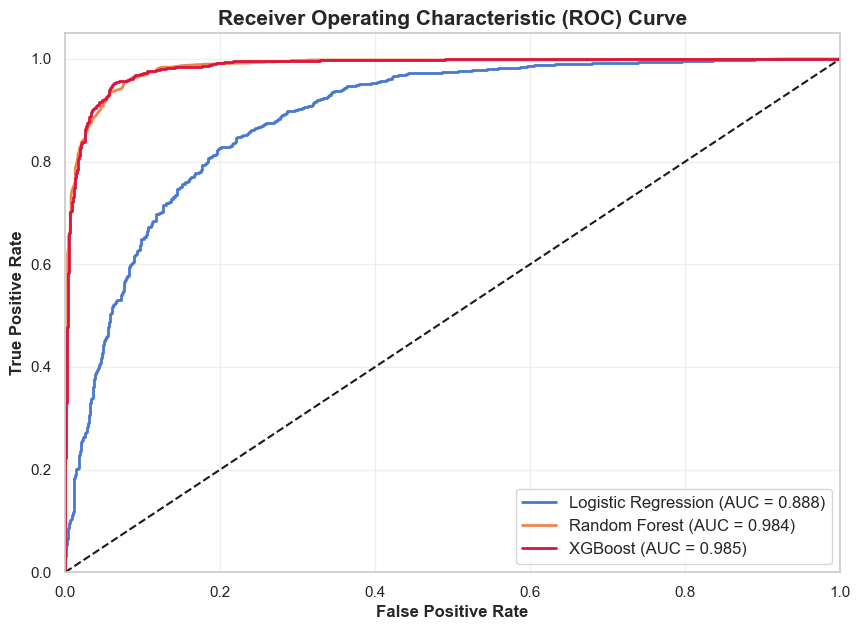

In [13]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:, 1])
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})', linewidth=2)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', linewidth=2)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_clf.predict_proba(X_test)[:, 1])
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})', linewidth=2, color='crimson')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()


## 6. Conclusion
After evaluating the models, it looks like tree-based models (Random Forest and XGBoost) handle the relationships in this medical dataset better than a simple linear model like Logistic Regression.

**Why this matters:**
- **Proactive Interventions:** By focusing on the top risk drivers (Age, BMI, Blood Pressure, Cholesterol), medical teams can suggest lifestyle changes earlier.
- **Resource Allocation:** Predictive models like this can help clinics identify which patients might need closer monitoring, potentially saving time and resources down the line.

**Next Steps:**
- A logical next step would be deploying the XGBoost model as a simple web app using Streamlit to see it in action.
- Trying out more advanced feature engineering, like combining Diet and Exercise into a single lifestyle score, might also improve the model further.
